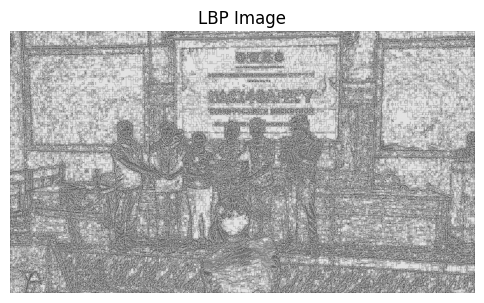

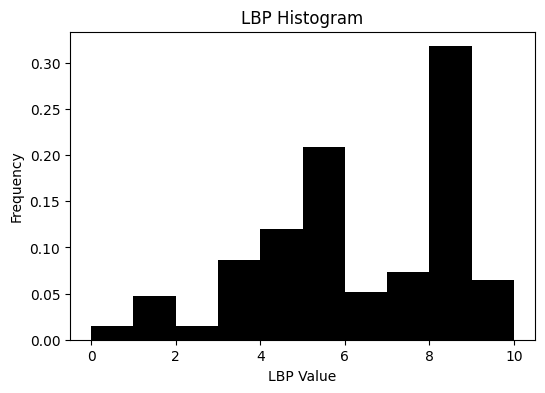

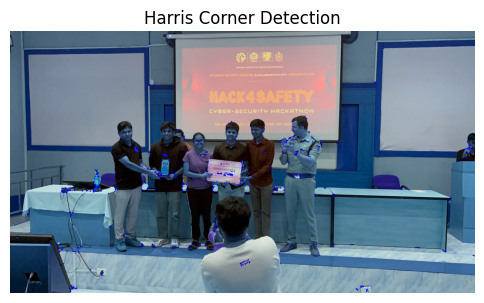

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern

def compute_lbp(image, radius=1, n_points=8, method='uniform'):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, n_points, radius, method)
    return lbp

def plot_lbp_histogram(lbp_image):
    lbp_flat = lbp_image.ravel()
    hist, bins = np.histogram(lbp_flat, bins=np.arange(0, np.max(lbp_flat) + 2), density=True)
    plt.figure(figsize=(6, 4))
    plt.bar(bins[:-1], hist, width=1, align='edge', color='black')
    plt.title('LBP Histogram')
    plt.xlabel('LBP Value')
    plt.ylabel('Frequency')
    plt.show()

def harris_corner_detection(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = np.float32(gray)
    corners = cv2.cornerHarris(gray, 2, 3, 0.04)
    corners = cv2.dilate(corners, None)
    image[corners > 0.01 * corners.max()] = [0, 0, 255]
    return image, corners

def main(image_path):
    image = cv2.imread(image_path)
    lbp_image = compute_lbp(image)
    plt.figure(figsize=(6, 6))
    plt.imshow(lbp_image, cmap='gray')
    plt.title('LBP Image')
    plt.axis('off')
    plt.show()
    plot_lbp_histogram(lbp_image)
    result_image, corners = harris_corner_detection(image.copy())
    plt.figure(figsize=(6, 6))
    plt.imshow(result_image)
    plt.title('Harris Corner Detection')
    plt.axis('off')
    plt.show()
    cv2.imwrite('harris_corners_output.png', result_image)

if __name__ == "__main__":
    image_path = '/content/nit rourkela winning photo.jpg'
    main(image_path)
